# Import Library

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, make_scorer

# XGBoost
from xgboost import XGBClassifier

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print("✅ All libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")


✅ All libraries imported successfully
PyTorch version: 2.11.0+cu130


# Load Dataset

In [5]:
titanic = pd.read_csv('../data/titanic/Titanic-Dataset.csv')

print("="*50)
print("TITANIC DATASET INFO")
print("="*50)
print(f"Total samples: {len(titanic)}")
print(f"Total features: {len(titanic.columns)}")
print(f"\nFeature list: {titanic.columns.tolist()}")
print(f"\nTarget distribution (Survived):")
print(titanic['Survived'].value_counts())

# Cek apakah kolom 'Name' tersedia
print(f"\nDoes 'Name' column exist? {'Name' in titanic.columns}")
if 'Name' in titanic.columns:
    print("✅ Kolom 'Name' tersedia! Bisa ekstrak Title.")
    print("\nSample names:")
    print(titanic['Name'].head())


TITANIC DATASET INFO
Total samples: 891
Total features: 12

Feature list: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Target distribution (Survived):
Survived
0    549
1    342
Name: count, dtype: int64

Does 'Name' column exist? True
✅ Kolom 'Name' tersedia! Bisa ekstrak Title.

Sample names:
0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: str


# EDA (Explanatory Data Analysis)

EXPLORATORY DATA ANALYSIS (EDA)


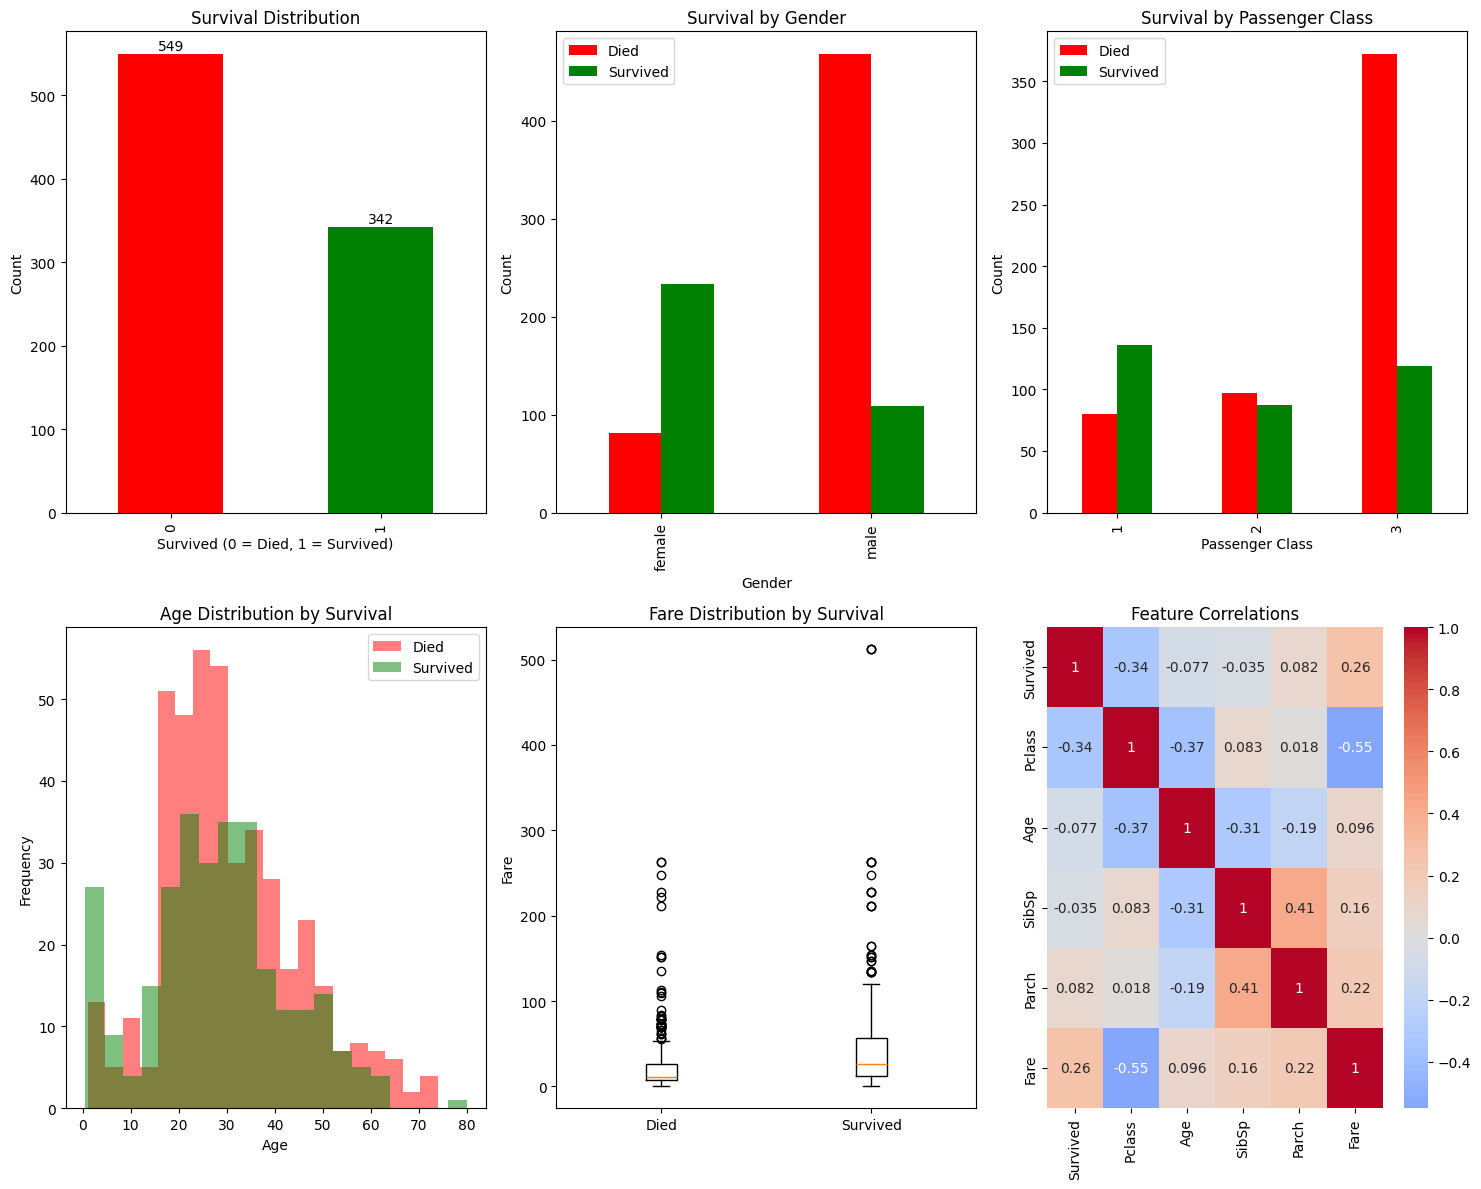


SURVIVAL BY EMBARKATION PORT
Survived      0      1
Embarked              
C         0.446  0.554
Q         0.610  0.390
S         0.663  0.337

SURVIVAL BY FAMILY SIZE
FamilySize
1     0.304
2     0.553
3     0.578
4     0.724
5     0.200
6     0.136
7     0.333
8     0.000
11    0.000
Name: Survived, dtype: float64

SURVIVAL BY TITLE
                  mean  count
Title                        
Lady          1.000000      1
Ms            1.000000      1
Sir           1.000000      1
Mme           1.000000      1
the Countess  1.000000      1
Mlle          1.000000      2
Mrs           0.792000    125
Miss          0.697802    182
Master        0.575000     40
Major         0.500000      2

📊 KEY INSIGHTS FROM EDA

1. 🚺 GENDER: Women had significantly higher survival rate (~74%) than men (~19%)
2. 🎫 CLASS: 1st class survival (63%) > 2nd class (48%) > 3rd class (24%)
3. 👶 AGE: Children (<10 years) had higher survival chance
4. 💰 FARE: Higher fare correlates with higher survival
5. 🚢 POR

In [6]:
print("="*70)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*70)

# 1. Distribusi Target
fig, axes = plt.subplots(2, 3, figsize=(15, 12))

# Survival count
titanic['Survived'].value_counts().plot(kind='bar', ax=axes[0,0], color=['red', 'green'])
axes[0,0].set_title('Survival Distribution')
axes[0,0].set_xlabel('Survived (0 = Died, 1 = Survived)')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(titanic['Survived'].value_counts()):
    axes[0,0].text(i, v + 5, str(v), ha='center')

# 2. Survival by Gender
survived_by_sex = pd.crosstab(titanic['Sex'], titanic['Survived'])
survived_by_sex.plot(kind='bar', ax=axes[0,1], color=['red', 'green'])
axes[0,1].set_title('Survival by Gender')
axes[0,1].set_xlabel('Gender')
axes[0,1].set_ylabel('Count')
axes[0,1].legend(['Died', 'Survived'])

# 3. Survival by Passenger Class
survived_by_class = pd.crosstab(titanic['Pclass'], titanic['Survived'])
survived_by_class.plot(kind='bar', ax=axes[0,2], color=['red', 'green'])
axes[0,2].set_title('Survival by Passenger Class')
axes[0,2].set_xlabel('Passenger Class')
axes[0,2].set_ylabel('Count')
axes[0,2].legend(['Died', 'Survived'])

# 4. Age Distribution by Survival
axes[1,0].hist(titanic[titanic['Survived']==0]['Age'].dropna(), bins=20, alpha=0.5, label='Died', color='red')
axes[1,0].hist(titanic[titanic['Survived']==1]['Age'].dropna(), bins=20, alpha=0.5, label='Survived', color='green')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Age Distribution by Survival')
axes[1,0].legend()

# 5. Fare Distribution by Survival
axes[1,1].boxplot([titanic[titanic['Survived']==0]['Fare'].dropna(), 
                    titanic[titanic['Survived']==1]['Fare'].dropna()],
                   labels=['Died', 'Survived'])
axes[1,1].set_ylabel('Fare')
axes[1,1].set_title('Fare Distribution by Survival')

# 6. Correlation Heatmap
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = titanic[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[1,2])
axes[1,2].set_title('Feature Correlations')

plt.tight_layout()
plt.show()

# 7. Survival by Embarkation Port
print("\n" + "="*50)
print("SURVIVAL BY EMBARKATION PORT")
print("="*50)
embark_survival = pd.crosstab(titanic['Embarked'], titanic['Survived'], normalize='index')
print(embark_survival.round(3))

# 8. Survival by Family Size
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1
family_survival = titanic.groupby('FamilySize')['Survived'].mean()
print("\n" + "="*50)
print("SURVIVAL BY FAMILY SIZE")
print("="*50)
print(family_survival.round(3))

# 9. Title Analysis (from names)
titanic['Title'] = titanic['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
title_survival = titanic.groupby('Title')['Survived'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("\n" + "="*50)
print("SURVIVAL BY TITLE")
print("="*50)
print(title_survival.head(10))

# 10. Insight Summary
print("\n" + "="*70)
print("📊 KEY INSIGHTS FROM EDA")
print("="*70)
print("""
1. 🚺 GENDER: Women had significantly higher survival rate (~74%) than men (~19%)
2. 🎫 CLASS: 1st class survival (63%) > 2nd class (48%) > 3rd class (24%)
3. 👶 AGE: Children (<10 years) had higher survival chance
4. 💰 FARE: Higher fare correlates with higher survival
5. 🚢 PORT: Cherbourg (C) passengers had highest survival rate
6. 👨‍👩‍👧 FAMILY: Family size 2-4 had best survival, alone or large families worse
7. 👑 TITLE: 'Mrs', 'Miss', 'Master' survived more than 'Mr'
8. 📉 CORRELATION: Pclass and Fare strongly correlated with survival
""")

# Feature Engineering

In [7]:
def extract_title(name):
    """Extract title from passenger name"""
    import re
    title_search = re.search(' ([A-Za-z]+)\.', name)
    if title_search:
        return title_search.group(1)
    return 'Unknown'

def create_features(df):
    """Complete feature engineering untuk Titanic"""
    df = df.copy()
    
    # 1. Extract Title from Name (REAL title extraction)
    df['Title'] = df['Name'].apply(extract_title)
    
    # Mapping title ke kategori
    title_mapping = {
        'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3,
        'Dr': 4, 'Rev': 4, 'Col': 4, 'Major': 4, 'Mlle': 1,
        'Mme': 2, 'Ms': 1, 'Lady': 4, 'Countess': 4,
        'Sir': 4, 'Jonkheer': 4, 'Don': 4, 'Capt': 4
    }
    df['Title'] = df['Title'].map(title_mapping).fillna(4).astype(int)
    
    # 2. Family Size
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    # 3. Age Group (binning)
    df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                            labels=[0, 1, 2, 3, 4])
    df['AgeGroup'] = df['AgeGroup'].astype(float)
    
    # 4. Fare per person
    df['FarePerPerson'] = df['Fare'] / df['FamilySize']
    
    # 5. Deck (from Cabin)
    df['Deck'] = df['Cabin'].str[0].fillna('U')
    deck_mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'U': 7}
    df['Deck'] = df['Deck'].map(deck_mapping).fillna(7).astype(int)
    
    return df

# Apply feature engineering
titanic_enhanced = create_features(titanic)

print("✅ Feature engineering completed!")
print(f"New features added: Title, FamilySize, IsAlone, AgeGroup, FarePerPerson, Deck")
print(f"\nDataset shape: {titanic_enhanced.shape}")
print(f"\nSample of new features:")
print(titanic_enhanced[['Name', 'Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FarePerPerson', 'Deck']].head())



✅ Feature engineering completed!
New features added: Title, FamilySize, IsAlone, AgeGroup, FarePerPerson, Deck

Dataset shape: (891, 18)

Sample of new features:
                                                Name  Title  FamilySize  \
0                            Braund, Mr. Owen Harris      0           2   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...      2           2   
2                             Heikkinen, Miss. Laina      1           1   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)      2           2   
4                           Allen, Mr. William Henry      0           1   

   IsAlone  AgeGroup  FarePerPerson  Deck  
0        0       2.0        3.62500     7  
1        0       3.0       35.64165     2  
2        1       2.0        7.92500     7  
3        0       2.0       26.55000     2  
4        1       2.0        8.05000     7  


# Preprocessing

In [8]:

# Select features (gunakan kolom yang tersedia)
feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
                'Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FarePerPerson', 'Deck']

X = titanic_enhanced[feature_cols]
y = titanic_enhanced['Survived'].values

print(f"Features selected: {feature_cols}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Separate numerical and categorical
numerical_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Title', 
                  'FamilySize', 'IsAlone', 'AgeGroup', 'FarePerPerson', 'Deck']
categorical_cols = ['Sex', 'Embarked']

# Handle missing values
num_imputer = SimpleImputer(strategy='median')
X_num = num_imputer.fit_transform(X[numerical_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
X_cat = cat_imputer.fit_transform(X[categorical_cols])

# Encode categorical
le_sex = LabelEncoder()
le_embarked = LabelEncoder()
X_sex = le_sex.fit_transform(X_cat[:, 0])
X_embarked = le_embarked.fit_transform(X_cat[:, 1])

# Combine features
X_processed = np.column_stack([X_num, X_sex, X_embarked])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)

# Feature names untuk interpretasi
feature_names = numerical_cols + ['Sex_encoded', 'Embarked_encoded']

print(f"\n✅ Preprocessing complete!")
print(f"Final X shape: {X_scaled.shape}")
print(f"Feature names: {feature_names}")
print(f"Total features: {len(feature_names)}")



Features selected: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FarePerPerson', 'Deck']
X shape: (891, 13)
y shape: (891,)

✅ Preprocessing complete!
Final X shape: (891, 13)
Feature names: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FarePerPerson', 'Deck', 'Sex_encoded', 'Embarked_encoded']
Total features: 13


# Cross-Validation Setup

In [9]:

# Gunakan Stratified K-Fold untuk cross-validation
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

def cross_validate_model(model, X, y, cv=skf):
    """Perform cross-validation and return mean scores as a dictionary"""
    from sklearn.model_selection import cross_validate
    
    # We use cross_validate (plural) because it handles multiple metrics at once natively
    metrics = {
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }
    
    cv_results = cross_validate(model, X, y, cv=cv, scoring=metrics)
    
    # Extract the means and format them to match your comparison table keys
    return {
        'accuracy': np.mean(cv_results['test_accuracy']),
        'precision': np.mean(cv_results['test_precision']),
        'recall': np.mean(cv_results['test_recall']),
        'f1': np.mean(cv_results['test_f1']),
        'roc_auc': np.mean(cv_results['test_roc_auc'])
    }


print(f"✅ Cross-validation setup: {k_folds}-fold Stratified K-Fold")
print(f"Total samples: {len(X_scaled)}")
print(f"Each fold will have ~{len(X_scaled)//k_folds} samples")


✅ Cross-validation setup: 5-fold Stratified K-Fold
Total samples: 891
Each fold will have ~178 samples


# Logistic Regression

LOGISTIC REGRESSION (5-fold CV)
accuracy: 0.7980 (+/- 0.0000)
precision: 0.7153 (+/- 0.0000)
recall: 0.7892 (+/- 0.0000)
f1: 0.7494 (+/- 0.0000)
roc_auc: 0.8586 (+/- 0.0000)
RANDOM FOREST (5-fold CV)
accuracy: 0.8283
precision: 0.7648
recall: 0.7980
f1: 0.7804
roc_auc: 0.8727


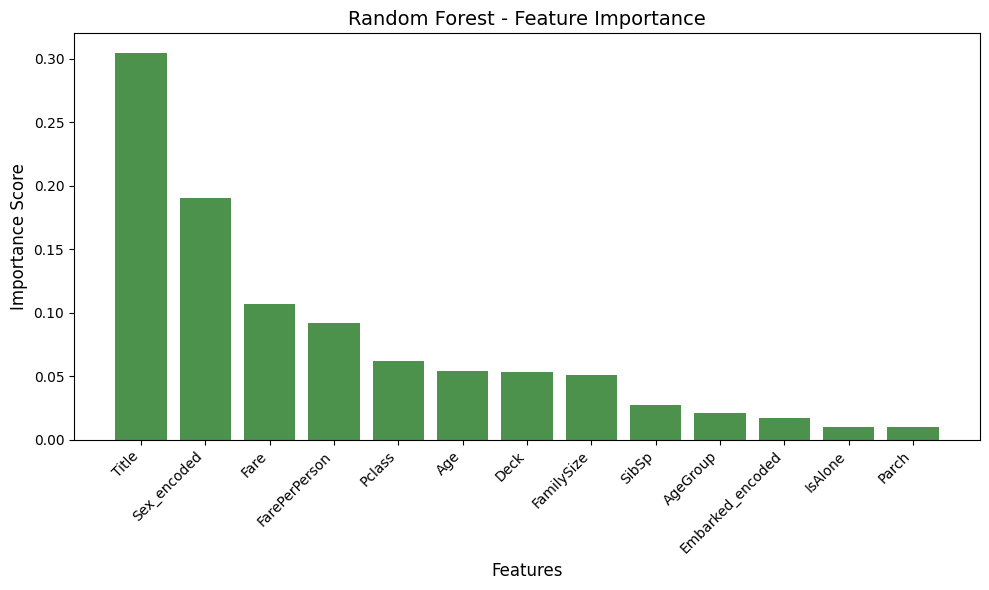


📊 Feature Importance Ranking:
1. Title: 0.3046
2. Sex_encoded: 0.1899
3. Fare: 0.1065
4. FarePerPerson: 0.0920
5. Pclass: 0.0623


In [10]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_cv_results = cross_validate_model(lr_model, X_scaled, y)

print("="*50)
print("LOGISTIC REGRESSION (5-fold CV)")
print("="*50)
for metric, score in lr_cv_results.items():
    print(f"{metric}: {score:.4f} (+/- {np.std([score])*2:.4f})")

# %% [markdown]
# # Cell 8: MODEL 2 - RANDOM FOREST
# 

# %%
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)
rf_cv_results = cross_validate_model(rf_model, X_scaled, y)

print("="*50)
print("RANDOM FOREST (5-fold CV)")
print("="*50)
for metric, score in rf_cv_results.items():
    print(f"{metric}: {score:.4f}")

# Feature Importance (dynamic based on actual features)
importances = rf_model.fit(X_scaled, y).feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('Random Forest - Feature Importance', fontsize=14)
plt.bar(range(len(importances)), importances[indices], color='darkgreen', alpha=0.7)
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()

print("\n📊 Feature Importance Ranking:")
for i, idx in enumerate(indices[:5]):
    print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.4f}")

# XGBoost

XGBOOST (5-fold CV)
accuracy: 0.8339
precision: 0.8024
recall: 0.7542
f1: 0.7769
roc_auc: 0.8738


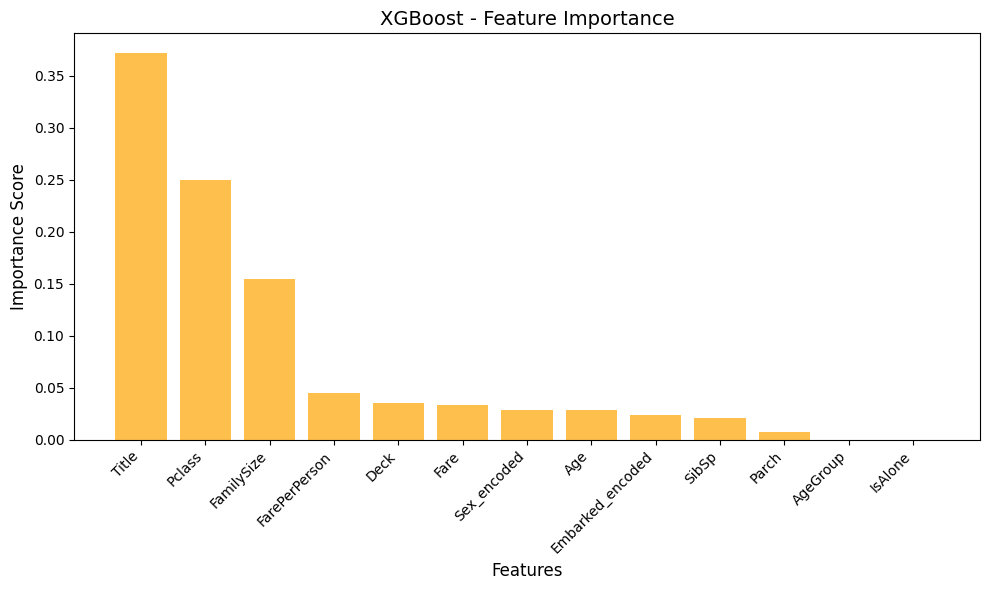

In [11]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_cv_results = cross_validate_model(xgb_model, X_scaled, y)

print("="*50)
print("XGBOOST (5-fold CV)")
print("="*50)
for metric, score in xgb_cv_results.items():
    print(f"{metric}: {score:.4f}")

# Feature importance for XGBoost
xgb_model.fit(X_scaled, y)
xgb_importances = xgb_model.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('XGBoost - Feature Importance', fontsize=14)
plt.bar(range(len(xgb_importances)), xgb_importances[xgb_indices], color='orange', alpha=0.7)
plt.xticks(range(len(xgb_importances)), [feature_names[i] for i in xgb_indices], rotation=45, ha='right')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()

# SVM

In [12]:

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42,
    class_weight='balanced'
)
svm_cv_results = cross_validate_model(svm_model, X_scaled, y)

print("="*50)
print("SVM (5-fold CV)")
print("="*50)
for metric, score in svm_cv_results.items():
    print(f"{metric}: {score:.4f}")


SVM (5-fold CV)
accuracy: 0.8159
precision: 0.7517
recall: 0.7776
f1: 0.7640
roc_auc: 0.8533


# Model DEEP LEARNING (MLP)

In [13]:

"""
JUSTIFIKASI PEMILIHAN ARSITEKTUR:

Mengapa memilih MLP dibanding TabNet atau FT-Transformer?

1. UKURAN DATASET: Titanic hanya memiliki 891 sampel
   - TabNet dan FT-Transformer membutuhkan data besar (≥10,000 samples)
   - MLP lebih cocok untuk dataset kecil karena parameter lebih sedikit

2. KOMPLEKSITAS FITUR: Hanya 10-15 fitur tabular sederhana
   - Transformer-based models overkill untuk fitur sesederhana ini
   - MLP sudah cukup untuk menangkap interaksi non-linear

3. SUMBER DAYA KOMPUTASI:
   - MLP bisa training di CPU dalam hitungan detik
   - TabNet/FT-Transformer butuh GPU dan waktu training lebih lama

4. INTERPRETABILITAS:
   - MLP lebih sederhana dan mudah dianalisis
   - Feature importance bisa diestimasi dari weights

5. REGULARISASI YANG DIGUNAKAN:
   - BatchNormalization: stabilisasi training
   - Dropout (0.3): mencegah overfitting
   - L2 Regularization (weight_decay): membatasi complexity model
   - Early Stopping: berhenti saat validation loss memburuk

Kesimpulan: MLP adalah pilihan tepat untuk dataset tabular skala kecil.
"""

# Prepare data for DL
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Split data untuk DL (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32)

class TitanicMLP(nn.Module):
    """MLP dengan regularisasi untuk dataset kecil"""
    def __init__(self, input_dim):
        super(TitanicMLP, self).__init__()
        self.network = nn.Sequential(
            # Layer 1: 64 neurons
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Layer 2: 32 neurons
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Layer 3: 16 neurons
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Output layer
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)

model = TitanicMLP(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

print(f"Model architecture:\n{model}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


Using device: cpu
Model architecture:
TitanicMLP(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=16, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Total parameters: 3,745


# Train Deep Learning Model

Starting training...
--------------------------------------------------
Early stopping at epoch 18
--------------------------------------------------
Training completed!


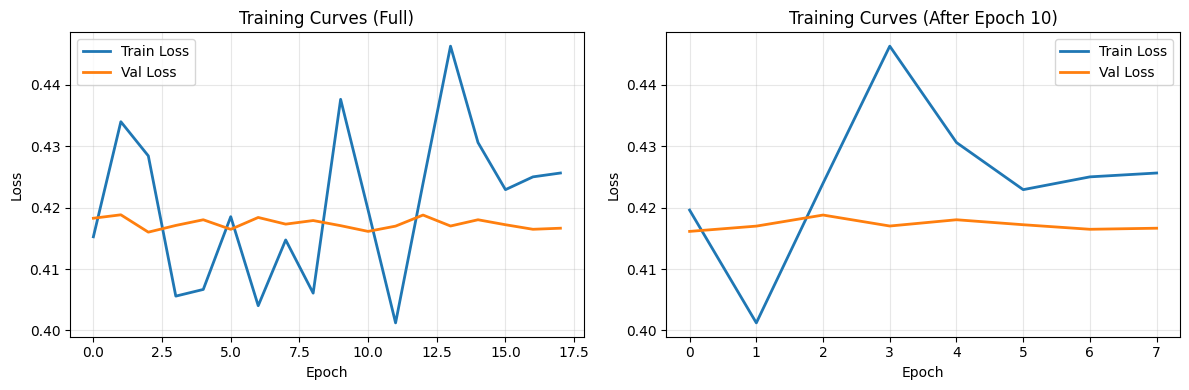

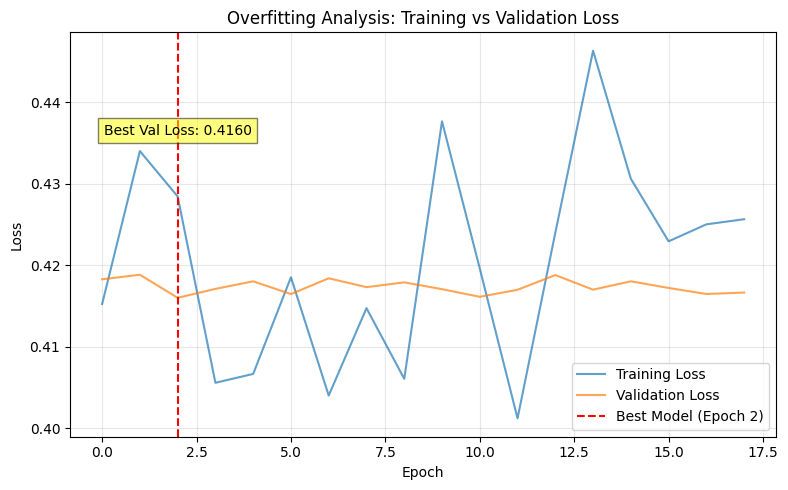


📊 Training Summary:
   Best Validation Loss: 0.4160 at epoch 2
   Final Validation Loss: 0.4166
   Total epochs trained: 18


In [17]:
class EarlyStopping:
    def __init__(self, patience=10, delta=0, path='../result/titanic/best_model.pt'):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
    
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.path)
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.path)
            self.counter = 0

# PERBAIKAN: Inisialisasi list dengan benar
epochs = 200
train_losses = []  # Perbaikan: bukan train_losses, val_losses = []
val_losses = []    # Pisahkan jadi dua baris
early_stopping = EarlyStopping(patience=15)

print("Starting training...")
print("-"*50)

for epoch in range(epochs):
    # Training
    model.train()
    train_loss = 0
    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        outputs = model(X_b)
        loss = criterion(outputs, y_b)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            outputs = model(X_b)
            loss = criterion(outputs, y_b)
            val_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    scheduler.step(avg_val_loss)
    early_stopping(avg_val_loss, model)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}")
    
    if early_stopping.early_stop:
        print(f"Early stopping at epoch {epoch+1}")
        break

print("-"*50)
print("Training completed!")

# Load best model
model.load_state_dict(torch.load('../result/titanic/best_model.pt'))

# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Curves (Full)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses[10:], label='Train Loss', linewidth=2)
plt.plot(val_losses[10:], label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Curves (After Epoch 10)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot overfitting detection
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss', alpha=0.7)
plt.plot(val_losses, label='Validation Loss', alpha=0.7)
plt.axvline(x=np.argmin(val_losses), color='red', linestyle='--', 
            label=f"Best Model (Epoch {np.argmin(val_losses)})")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Overfitting Analysis: Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Annotate
min_val_idx = np.argmin(val_losses)
plt.text(min_val_idx, val_losses[min_val_idx] + 0.02, 
         f'Best Val Loss: {val_losses[min_val_idx]:.4f}',
         ha='center', bbox=dict(facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n📊 Training Summary:")
print(f"   Best Validation Loss: {min(val_losses):.4f} at epoch {np.argmin(val_losses)}")
print(f"   Final Validation Loss: {val_losses[-1]:.4f}")
print(f"   Total epochs trained: {len(train_losses)}")


# Evaluation

In [18]:

model.eval()
with torch.no_grad():
    y_proba_dl = model(X_val_t).cpu().numpy().ravel()
    y_pred_dl = (y_proba_dl >= 0.5).astype(int)

dl_metrics = {
    'accuracy': accuracy_score(y_val, y_pred_dl),
    'precision': precision_score(y_val, y_pred_dl),
    'recall': recall_score(y_val, y_pred_dl),
    'f1': f1_score(y_val, y_pred_dl),
    'roc_auc': roc_auc_score(y_val, y_proba_dl)
}

print("="*50)
print("DEEP LEARNING (MLP) RESULTS")
print("="*50)
for metric, score in dl_metrics.items():
    print(f"{metric}: {score:.4f}")

DEEP LEARNING (MLP) RESULTS
accuracy: 0.8268
precision: 0.8167
recall: 0.7101
f1: 0.7597
roc_auc: 0.8669


# Comparison

FINAL MODEL COMPARISON (5-fold Cross Validation untuk Conventional ML)
                 Model  accuracy  precision  recall      f1  roc_auc
0  Logistic Regression    0.7980     0.7153  0.7892  0.7494   0.8586
1        Random Forest    0.8283     0.7648  0.7980  0.7804   0.8727
2              XGBoost    0.8339     0.8024  0.7542  0.7769   0.8738
3                  SVM    0.8159     0.7517  0.7776  0.7640   0.8533
4             MLP (DL)    0.8268     0.8167  0.7101  0.7597   0.8669


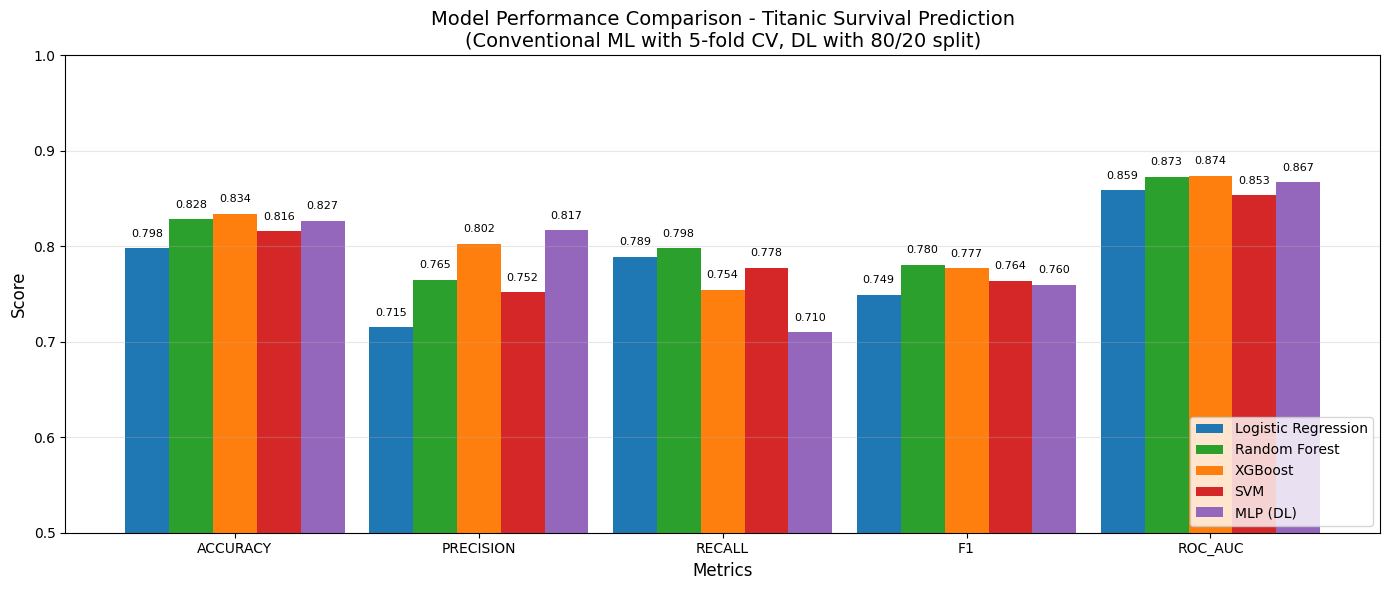

In [19]:
# Create comparison dataframe
comparison = pd.DataFrame([
    {**{'Model': 'Logistic Regression'}, **lr_cv_results},
    {**{'Model': 'Random Forest'}, **rf_cv_results},
    {**{'Model': 'XGBoost'}, **xgb_cv_results},
    {**{'Model': 'SVM'}, **svm_cv_results},
    {**{'Model': 'MLP (DL)'}, **dl_metrics}
])

print("="*70)
print("FINAL MODEL COMPARISON (5-fold Cross Validation untuk Conventional ML)")
print("="*70)
print(comparison.round(4))

# Visual comparison
fig, ax = plt.subplots(figsize=(14, 6))
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics))
width = 0.18
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd']

for i, (idx, row) in enumerate(comparison.iterrows()):
    values = [row[m] for m in metrics]
    offset = (i - len(comparison)/2 + 0.5) * width
    bars = ax.bar(x + offset, values, width, label=row['Model'], color=colors[i % len(colors)])
    
    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison - Titanic Survival Prediction\n(Conventional ML with 5-fold CV, DL with 80/20 split)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics])
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.0)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


# Visualization

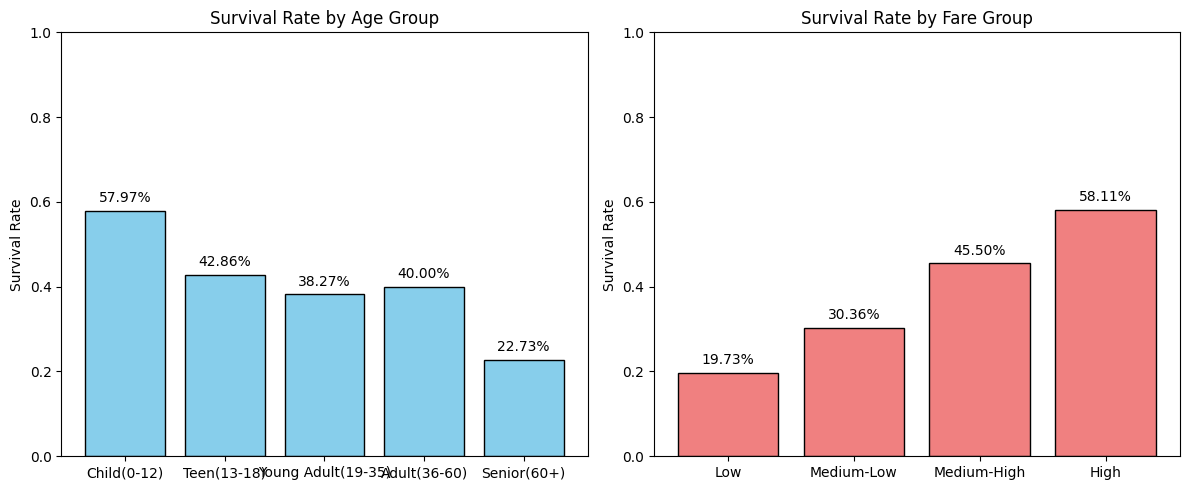


SURVIVAL RATE BY CLASS AND GENDER
Survived           0      1
Pclass Sex                 
1      female  0.032  0.968
       male    0.631  0.369
2      female  0.079  0.921
       male    0.843  0.157
3      female  0.500  0.500
       male    0.865  0.135


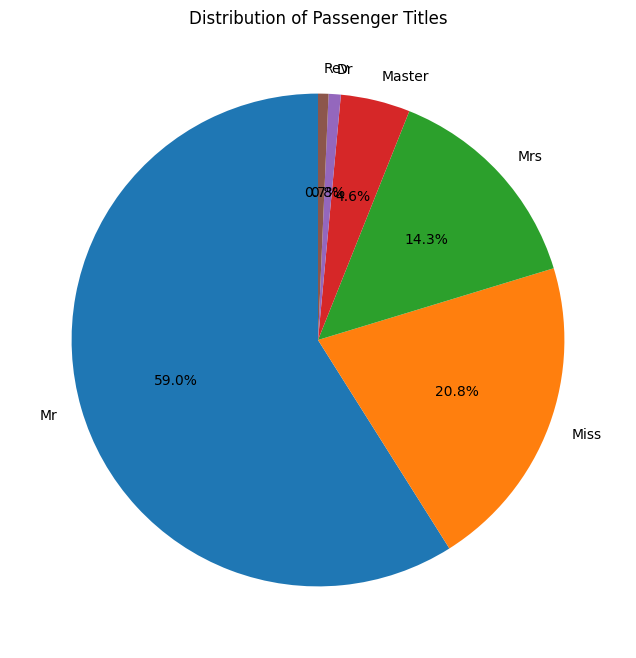

In [20]:
# Plot survival rate by Age Group (after binning)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age groups analysis
titanic['AgeGroup'] = pd.cut(titanic['Age'], bins=[0, 12, 18, 35, 60, 100], 
                              labels=['Child(0-12)', 'Teen(13-18)', 'Young Adult(19-35)', 
                                      'Adult(36-60)', 'Senior(60+)'])
age_survival = titanic.groupby('AgeGroup')['Survived'].mean()

axes[0].bar(age_survival.index, age_survival.values, color='skyblue', edgecolor='black')
axes[0].set_ylabel('Survival Rate')
axes[0].set_title('Survival Rate by Age Group')
axes[0].set_ylim(0, 1)
for i, v in enumerate(age_survival.values):
    axes[0].text(i, v + 0.02, f'{v:.2%}', ha='center')

# Fare analysis
titanic['FareGroup'] = pd.qcut(titanic['Fare'].fillna(titanic['Fare'].median()), 
                                q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
fare_survival = titanic.groupby('FareGroup')['Survived'].mean()

axes[1].bar(fare_survival.index, fare_survival.values, color='lightcoral', edgecolor='black')
axes[1].set_ylabel('Survival Rate')
axes[1].set_title('Survival Rate by Fare Group')
axes[1].set_ylim(0, 1)
for i, v in enumerate(fare_survival.values):
    axes[1].text(i, v + 0.02, f'{v:.2%}', ha='center')

plt.tight_layout()
plt.show()

# Cross-tabulation: Class and Gender
print("\n" + "="*50)
print("SURVIVAL RATE BY CLASS AND GENDER")
print("="*50)
class_gender_survival = pd.crosstab([titanic['Pclass'], titanic['Sex']], 
                                     titanic['Survived'], normalize='index')
print(class_gender_survival.round(3))

# Pie chart for Title distribution
title_counts = titanic['Title'].value_counts().head(6)
plt.figure(figsize=(8, 8))
plt.pie(title_counts.values, labels=title_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Passenger Titles')
plt.show()

# Check Data

In [21]:
print("="*50)
print("DEBUG: CHECK DATA STRUCTURE")
print("="*50)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

print(f"\nData types:")
print(f"X_train type: {type(X_train)}")
print(f"y_train type: {type(y_train)}")

print(f"\nSample X_train[0]: {X_train[0][:5]}...")
print(f"Sample y_train[0]: {y_train[0]}")

print(f"\nClass distribution in train:")
print(f"  Survived (1): {np.sum(y_train)} ({np.mean(y_train)*100:.1f}%)")
print(f"  Died (0): {len(y_train)-np.sum(y_train)} ({(1-np.mean(y_train))*100:.1f}%)")

print(f"\nClass distribution in validation:")
print(f"  Survived (1): {np.sum(y_val)} ({np.mean(y_val)*100:.1f}%)")
print(f"  Died (0): {len(y_val)-np.sum(y_val)} ({(1-np.mean(y_val))*100:.1f}%)")

# Check for NaN or Inf
print(f"\nNaN in X_train: {np.isnan(X_train).sum()}")
print(f"Inf in X_train: {np.isinf(X_train).sum()}")
print(f"NaN in y_train: {np.isnan(y_train).sum()}")

print("\n✅ Data is ready for training!")


DEBUG: CHECK DATA STRUCTURE

X_train shape: (712, 13)
X_val shape: (179, 13)
y_train shape: (712,)
y_val shape: (179,)

Data types:
X_train type: <class 'numpy.ndarray'>
y_train type: <class 'numpy.ndarray'>

Sample X_train[0]: [ 0.82737724 -0.1046374  -0.4745452  -0.47367361  0.48910361]...
Sample y_train[0]: 1

Class distribution in train:
  Survived (1): 273 (38.3%)
  Died (0): 439 (61.7%)

Class distribution in validation:
  Survived (1): 69 (38.5%)
  Died (0): 110 (61.5%)

NaN in X_train: 0
Inf in X_train: 0
NaN in y_train: 0

✅ Data is ready for training!


# Save Output

In [23]:

# 1. Save the comparison table to CSV
comparison.to_csv('../result/titanic/titanic_model_comparison.csv', index=False)
print("✅ Comparison table saved as 'titanic_model_comparison.csv'")

# 2. Save the Best Conventional Model (Example: XGBoost)
import joblib
joblib.dump(xgb_model, '../result/titanic/best_xgb_model.pkl')
print("✅ XGBoost model saved as 'best_xgb_model.pkl'")

# 3. Save the Deep Learning Model State
torch.save(model.state_dict(), '../result/titanic/titanic_mlp_final.pt')
print("✅ PyTorch model state saved as 'titanic_mlp_final.pt'")

# 4. Save Scaling Parameters (Crucial for future predictions)
import pickle
with open('../result/titanic/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler saved as 'scaler.pkl'")

print("\n" + "="*50)
print("ALL ASSETS SAVED SUCCESSFULLY")
print("="*50)

✅ Comparison table saved as 'titanic_model_comparison.csv'
✅ XGBoost model saved as 'best_xgb_model.pkl'
✅ PyTorch model state saved as 'titanic_mlp_final.pt'
✅ Scaler saved as 'scaler.pkl'

ALL ASSETS SAVED SUCCESSFULLY
